# Hybrid glider vs. N-Sensor Defender: Strong Stackelberg Security Game (SSG)

This notebook extends the single-sensor SSG (`hybrid_glider_SSG.ipynb`) to a
**multi-sensor defender** that places exactly `N_SENSORS >= 1` co-located
radar + acoustic units anywhere on the perimeter candidate set `D_SITES`.

**Leader (defender).** Places `N_SENSORS` sensors chosen from `D_SITES`
(no repeated sites). Objective $J_D = \beta_1 P_D + \beta_2\,\mathrm{Coverage}$
(maximize), where Coverage is the **union** of the `N_SENSORS` coverage discs.

**Follower (attacker).** A boost-glide vehicle that best-responds to the full
sensor array. Detection intensities from all sensors are summed under
independent-Poisson fusion: $H = \int\sum_k\sum_j \lambda_{kj}\,\mathrm{d}t$,
$P_D = 1-e^{-H}$ (more sensors always hurts the attacker).

**Solution concept.** Strong Stackelberg Equilibrium (SSE) via deterministic
enumeration over $\binom{|D|}{N}$ sensor placements.

## Changes from the single-sensor notebook

| Component | Change |
|-----------|--------|
| `N_SENSORS` | new constant (set to 1 to reproduce original) |
| `hazard_glide`, `hazard_powered` | sum over `sensors` list |
| `glide_dp` | `sensor` → `sensors` list, sum radar rates |
| `coverage` | union of N coverage intervals |
| `attacker_BR` | `sensor` → `sensors` list |
| SSE sweep | `itertools.combinations(D_SITES, N_SENSORS)` |
| Baselines | naive = evenly-spaced; greedy = submodular coverage |
| Figure | Panel A bar chart for N>1; Panel B shows all sensor sites |

In [1]:
import math, time, heapq, itertools
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Constants, vehicle, mission, defender, threat, objectives

In [2]:
# --- physics / vehicle ---
G, RHO = 9.81, 1.225
M, S, CD = 1.5, 0.1, 0.025
CL_DISCRETE = tuple(np.linspace(0.1, 1.5, 10))
V_STALL, V_MAX = 14.0, 100.0
T_MAX = 25.0
THRUST_LEVELS = (0.0, T_MAX)

# --- mission geometry ---
Z_LAUNCH, H_LAUNCH = 0.0, 0.0
V_LAUNCH, GAM_LAUNCH = V_STALL, math.radians(45.0)
Z_GOAL, H_GOAL = 2500.0, 0.0
DT_GLIDE, DT_POW = 1.0, 0.25
V_MAX_GLIDE = 60.0

# --- DEFENDER (leader): N_SENSORS co-located radar+acoustic units on perimeter ---
N_SENSORS   = 2                                                    # >= 1; set to 1 for original
R_PERIM     = 2000.0
D_SITES     = np.arange(Z_GOAL - R_PERIM, Z_GOAL + 1, 250.0)     # candidate z positions (h=0)
CORRIDOR_Z0 = 500.0
R_DET       = 600.0

# --- threat model ---
# Calibrated to a low, separable P_D band (see 'Calibration & literature basis').
# Forms: radar r^-4 (radar range eq., Skolnik); aspect-dep. signature + range (Inanc et al., JGCD 2008);
# acoustic v^n / r^2 (rotor aeroacoustics + spherical spreading). Scale = reference-range anchor.
LAM_DOPPLER  = 4.5e2    # = 1.5e4 x 0.03
LAM_RCS      = 6.0e3    # = 2.0e5 x 0.03
SIGMA0, SIGMA_MIN = 1.0, 0.1
LAM_ACOUSTIC = 2.4e-3   # = 0.08 x 0.03
N_ACOUSTIC   = 4
R_FLOOR      = 10.0

# --- objectives ---
A1_PD, A2_T   = 1.0, 0.002
B1_PD, B2_COV = 1.0, 0.5

# --- glide cost shaping ---
W_TIME_GLIDE = 0.005
W_SMOOTH     = 0.1
W_SPEED      = 1.5
H_CLEAR      = 15.0
Z_FLARE      = 300.0
H_HEADROOM_G = 100.0

# --- powered cost ---
W_TIME_POW, W_FUEL_POW = 1.0, 0.1

# --- best-response / SSE controls ---
V_SW_FLOOR = 16.0
N_SWITCH   = 6
TIE_EPS    = 0.01

# --- state-grid resolutions ---
RANK_GRID  = dict(dz=100.0, dh=10.0, dv=4.0, dgam=math.radians(4.0))  # selection only
FINAL_GRID = dict(dz=50.0, dh=5.0, dv=2.0, dgam=math.radians(2.0))

print(f'N_SENSORS={N_SENSORS}, |D_SITES|={len(D_SITES)}, '
      f'placements to evaluate: C({len(D_SITES)},{N_SENSORS})='
      f'{len(list(itertools.combinations(D_SITES, N_SENSORS)))}')

N_SENSORS=2, |D_SITES|=9, placements to evaluate: C(9,2)=36


## Dynamics

In [3]:
def eom(v, gamma, CL, T):
    s, co = math.sin(gamma), math.cos(gamma)
    q = 0.5 * RHO * v * v * S
    return (v * co,
            v * s,
            -G * s - q * CD / M + T / M,
            q * CL / (M * v) - G * co / v)

def rk4(z, h, v, gamma, CL, dt, T):
    k1 = eom(v, gamma, CL, T)
    k2 = eom(v + k1[2]*dt/2, gamma + k1[3]*dt/2, CL, T)
    k3 = eom(v + k2[2]*dt/2, gamma + k2[3]*dt/2, CL, T)
    k4 = eom(v + k3[2]*dt,   gamma + k3[3]*dt,   CL, T)
    return (z + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            h + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            v + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]),
            gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3]))

## Threat model — multi-sensor Poisson fusion

Per-sensor intensities are unchanged. For a sensor array, intensities **add**
across sensors (independent Poisson channels), so:

$$H = \int_0^T \sum_{j=1}^{N} \bigl[\lambda_\mathrm{dop}^{(j)} + \lambda_\mathrm{rcs}^{(j)} + \lambda_\mathrm{ac}^{(j)}\bigr]\,\mathrm{d}t, \quad P_D = 1 - e^{-H}$$

`hazard_glide` and `hazard_powered` now accept a **list of sensor positions**.

In [4]:
def _range(z, h, sensor):
    r = math.hypot(z - sensor[0], h - sensor[1])
    return r if r > R_FLOOR else R_FLOOR

def doppler_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    dz, dh = z - sensor[0], h - sensor[1]
    vr = (v*math.cos(gamma)*dz + v*math.sin(gamma)*dh) / r
    return LAM_DOPPLER * vr*vr / r**4

def rcs_rate(z, h, v, gamma, sensor):
    r = _range(z, h, sensor)
    ez, eh = (sensor[0]-z)/r, (sensor[1]-h)/r
    c = ez*(-math.sin(gamma)) + eh*math.cos(gamma)
    sigma = SIGMA_MIN + (SIGMA0 - SIGMA_MIN) * c*c
    return LAM_RCS * sigma / r**4

def radar_rate(z, h, v, gamma, sensor):
    return doppler_rate(z, h, v, gamma, sensor) + rcs_rate(z, h, v, gamma, sensor)

def acoustic_rate(z, h, v, sensor):
    r = _range(z, h, sensor)
    return LAM_ACOUSTIC * v**N_ACOUSTIC / (r*r)

def hazard_glide(pts, sensors, dt_sub):
    '''Radar hazard over a glide trajectory, summed over all sensors.'''
    return sum(
        sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        for (z, h, v, g, _T) in pts[:-1]
    )

def hazard_powered(pts, sensors, dt_sub):
    '''Radar + acoustic hazard over a powered trajectory, summed over all sensors.'''
    cost = 0.0
    for (z, h, v, g, T) in pts[:-1]:
        cost += sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        if T > 0:
            cost += sum(acoustic_rate(z, h, v, s) for s in sensors) * dt_sub
    return cost

def pod_from_hazard(hz):
    return 1.0 - math.exp(-hz)

## Calibration and literature basis

The detection forms are standard; the scale is ours.

- **Exponential (Koopman) detection law.** $P_D = 1-\exp(-\int \eta\,dt)$ with instantaneous rate $\eta$ is Koopman search theory (Koopman, *Search and Screening*, 1980; Stone, *Theory of Optimal Search*, 1975). Independent multi-sensor fusion $1-P_{nd}=1-\prod_k(1-p_{d,k})$ reduces to summing intensities, which is what `hazard_*` do.
- **Radar $r^{-4}$.** Received power, hence SNR and detection rate, scale as $\sigma/R^4$ from the radar range equation (Skolnik, *Introduction to Radar Systems*).
- **Aspect-dependent signature + range.** $p_d=f(\text{signature}(\text{aspect}),\,R)$ and $P_{nd}=\prod_k(1-p_{d,k})$ follow Inanc, Muezzinoglu, Misovec, Murray, *Framework for Low-Observable Trajectory Generation in Presence of Multiple Radars*, J. Guidance, Control, and Dynamics 31(5), 2008 (CDC 2004 precursor); see also Pachter and Hebert, ACC 2001, for the radar-exposure integral.
- **Acoustic $v^n/r^2$.** Propeller/rotor broadband source level grows with tip speed ($n\approx4$–$6$) and intensity falls with $1/r^2$ spherical spreading (UAV-acoustic detection review, *AIP Advances* 2025; flyover measurements, *Applied Acoustics*).

**On $\lambda$.** No source gives a transferable numeric $\lambda$: in Inanc it is tabular data from a platform model, and in the radar equation $\lambda$ is a lumped system constant (transmit power, aperture, noise floor, detection threshold). The defensible practice is to fix $\lambda$ by a *reference detection range*, choosing it so that a best-responding attacker's $P_D$ stays in a band where the methods separate. We use a single scale (0.03 relative to the saturated setting) so that, with $N=2$ on the reporting grid, $P_D$ spans roughly 0.2 to 0.66 rather than pinning at 1; the SSE sits near 0.66 while coverage-greedy and naive sit near 0.22. Absolute $P_D$ is therefore calibration-dependent; the meaningful claim is the *relative* gap between strategies.

**Resolution note.** Because the radar hazard $\propto r^{-4}$ is sharply peaked at closest approach, integrated $P_D$ is grid/substep dependent through two competing effects: a coarser grid gives the attacker fewer states to evade through (raising $P_D$) but also under-resolves the hazard peak (lowering $P_D$), so coarse-grid $P_D$ can land either side of the fine-grid value. Selection uses the coarse ranking grid; all reported $P_D$ use the fine grid with finer substeps. For the paper, adaptive refinement near closest approach would make $P_D$ resolution-independent before $\lambda$ is fixed.

## State grids, snapping, and ground-clearance floor

In [5]:
def glide_grid(z_sw, h_sw, dz, dh, dv, dgam, hh):
    Z = np.arange(z_sw, Z_GOAL + dz, dz)
    H = np.arange(0.0, h_sw + hh + dh, dh)
    Vv = np.arange(V_STALL, V_MAX_GLIDE + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(45) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def pow_grid(dz, dh, dv, dgam, zmax, hmax):
    Z = np.arange(0.0, zmax + dz, dz)
    H = np.arange(0.0, hmax + dh, dh)
    Vv = np.arange(V_STALL, V_MAX + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(90) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def snap(gr, z, h, v, gamma):
    iz = int(round((z - gr['Z0']) / gr['dz']))
    ih = int(round((h - gr['H0']) / gr['dh']))
    iv = int(round((v - gr['V0']) / gr['dv']))
    ig = int(round((gamma - gr['G0']) / gr['dgam']))
    if 0 <= iz < gr['NZ'] and 0 <= ih < gr['NH'] and 0 <= iv < gr['NV'] and 0 <= ig < gr['NG']:
        return (iz, ih, iv, ig)
    return None

def minclear(z, hc, zf):
    d = Z_GOAL - z
    if d >= zf: return hc
    if d <= 0:  return 0.0
    return hc * d / zf

## Powered phase: Dijkstra DP (energy-only, solved once)

Detection-independent — solved once, reused for every sensor combination.

In [6]:
def powered_dp(gr, w_time, w_fuel):
    s0 = snap(gr, Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    V = {s0: 0.0}; prev = {}; cont = {s0: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap = [(0.0, 0, s0)]; cnt = 1; hmax = gr['H'][-1]
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        z, h, v, gm = cont[s]
        for T in THRUST_LEVELS:
            base = w_time * DT_POW + w_fuel * T * DT_POW
            for CL in CL_DISCRETE:
                zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_POW, T)
                if hn < 0 or zn < 0 or vn < V_STALL or hn > hmax: continue
                sn = snap(gr, zn, hn, vn, gn)
                if sn is None: continue
                nc = c + base
                if nc < V.get(sn, 1e18):
                    V[sn] = nc; prev[sn] = (s, CL, T); cont[sn] = (zn, hn, vn, gn)
                    heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0

def handoff_at(gr, V, cont, z_sw, h_sw):
    izp = int(round((z_sw - gr['Z0']) / gr['dz']))
    ihp = int(round((h_sw - gr['H0']) / gr['dh']))
    if not (0 <= izp < gr['NZ'] and 0 <= ihp < gr['NH']): return None
    best, bv = None, 1e18
    for iv in range(gr['NV']):
        for ig in range(gr['NG']):
            if gr['Gam'][ig] > 1e-9: continue  # only level/descending at handoff
            s = (izp, ihp, iv, ig)
            if s in V and V[s] < bv: bv, best = V[s], s
    if best is None: return None
    z, h, v, g = cont[best]
    return dict(state=best, z=z, h=h, v=v, gamma=g, cost=bv)   # <-- added z, h

## Glide phase: regularized Dijkstra DP against a sensor array

`sensors` is a list of `(z, h)` tuples. The step cost sums `radar_rate` across
all sensors (Poisson fusion). Setting `use_radar=False` gives the detection-blind
greedy baseline.

In [7]:
def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sensors, w_time, w_smooth, w_speed, hc, zf, hh,
             use_radar=True, z_init=None, h_init=None):
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None: return None
    izg = gr['NZ']-1
    z_c = z_init if z_init is not None else z_sw
    h_c = h_init if h_init is not None else h_sw
    V = {s0: 0.0}; prev = {}; cont = {s0: (z_c, h_c, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]; cnt = 1; ceil = h_sw + hh; goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        if s[0] == izg and s[1] == 0: goal = s; break
        z, h, v, gm = cont[s]
        pr = sum(radar_rate(z, h, v, gm, sen) for sen in sensors) if use_radar else 0.0
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_GLIDE, 0.0)
            if vn < V_STALL or hn > ceil: continue                  # <-- removed `zn < z_sw`
            # if hn < TERR(zn) + minclear(zn,hc,zf) - 1e-9: continue  # only second def has this line
            sn = snap(gr, zn, hn, vn, gn)
            if sn is None: continue
            nc = c + pr*DT_GLIDE + w_time*DT_GLIDE + w_smooth*abs(gn - gm) + w_speed*abs(vn - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc; prev[sn] = (s, CL); cont[sn] = (zn, hn, vn, gn)
                heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0, goal

## Smooth trajectory reconstruction

In [8]:
def reconstruct(prev, cont, s_goal, s0, dt, T_is_stored, substeps=8):
    seq = []; s = s_goal
    while s != s0 and s in prev:
        e = prev[s]
        if T_is_stored: ps, CL, Tt = e
        else:           ps, CL = e; Tt = 0.0
        seq.append((CL, Tt)); s = ps
    seq.reverse()
    z, h, v, g = cont[s0]; sub = dt / substeps
    pts = [(z, h, v, g, 0.0)]
    for CL, Tt in seq:
        for _ in range(substeps):
            z, h, v, g = rk4(z, h, v, g, CL, sub, Tt)
            pts.append((z, h, v, g, Tt))
    return pts

def count_steps(prev, s0, s_goal):
    n, s = 0, s_goal
    while s != s0 and s in prev:
        n += 1; s = prev[s][0]
    return n

## Coverage and defender objective

`coverage(sensors)` computes the **union** of all sensor coverage discs projected
onto the approach corridor, then normalizes by corridor length.
For `N_SENSORS=1` this reduces to the original formula.

In [9]:
def coverage(sensors):
    '''Union of coverage intervals across all sensors over [CORRIDOR_Z0, Z_GOAL].'''
    intervals = []
    for s in sensors:
        lo = max(CORRIDOR_Z0, s[0] - R_DET)
        hi = min(Z_GOAL,      s[0] + R_DET)
        if hi > lo:
            intervals.append((lo, hi))
    if not intervals:
        return 0.0
    intervals.sort()
    merged = [list(intervals[0])]
    for lo, hi in intervals[1:]:
        if lo <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], hi)
        else:
            merged.append([lo, hi])
    total = sum(hi - lo for lo, hi in merged)
    return total / (Z_GOAL - CORRIDOR_Z0)

def J_D(P_D, sensors):
    return B1_PD * P_D + B2_COV * coverage(sensors)

## Baseline placement helpers

- **Naive**: `N_SENSORS` sites chosen at evenly-spaced indices of `D_SITES`.
- **Greedy**: sequential submodular coverage maximization (pick the site with the
  highest marginal coverage gain at each step).

In [10]:
def naive_placement(n):
    '''n evenly-spaced sensors from D_SITES (by index).'''
    if n >= len(D_SITES):
        return [(float(z), 0.0) for z in D_SITES]
    idx = np.round(np.linspace(0, len(D_SITES) - 1, n)).astype(int)
    return [(float(D_SITES[i]), 0.0) for i in sorted(set(idx))]

def greedy_coverage_placement(n):
    '''Greedy submodular coverage: add one sensor at a time, maximizing marginal gain.'''
    placed = []
    available = [float(z) for z in D_SITES]
    for _ in range(n):
        best_site, best_cov = None, -1.0
        for z in available:
            c = coverage(placed + [(z, 0.0)])
            if c > best_cov:
                best_cov, best_site = c, z
        placed.append((best_site, 0.0))
        available = [z for z in available if z != best_site]
    return placed

def _sensors_key(sensors):
    '''Hashable key for a sensor list (sorted by z position).'''
    return tuple(sorted((round(s[0]), round(s[1])) for s in sensors))

## Follower oracle: attacker best response $\mathrm{BR}(\mathbf{z}_d)$

`attacker_BR(sensors, ...)` takes a **list of sensor positions** and returns the
switch minimizing $J_A = \alpha_1 P_D + \alpha_2 T$ with the strong tie-break.

In [11]:
def switch_candidates(grp, Vp, contp):
    raw = []
    for z_sw in np.arange(100.0, 300.0 + 1, 50.0):
        for h_sw in np.arange(40.0, 160.0 + 1, 20.0):
            ho = handoff_at(grp, Vp, contp, z_sw, h_sw)
            if ho is None or ho['v'] < V_SW_FLOOR: continue
            raw.append((z_sw, h_sw, ho))
    if len(raw) > N_SWITCH:
        idx = np.linspace(0, len(raw) - 1, N_SWITCH).round().astype(int)
        return [raw[i] for i in sorted(set(idx))]
    return raw

def attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands, grid=None, substeps=6,
                use_radar=True):
    grid = grid or RANK_GRID
    evals = []
    for z_sw, h_sw, ho in cands:
        gr = glide_grid(z_sw, h_sw, hh=H_HEADROOM_G, **grid)              # <-- nominal grid (back to original)
        out = glide_dp(gr, z_sw, h_sw, ho['v'], ho['gamma'], sensors,     # <-- nominal z_sw, h_sw
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                       use_radar=use_radar,
                       z_init=ho['z'], h_init=ho['h'])                    # <-- pass actual for cont[s0]
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        glide_pts = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=substeps)
        pow_pts   = reconstruct(prevp, contp, ho['state'], s0p, DT_POW, True, substeps=substeps)
        hz = (hazard_glide(glide_pts, sensors, DT_GLIDE/substeps)
              + hazard_powered(pow_pts, sensors, DT_POW/substeps))
        P_D = pod_from_hazard(hz)
        T = (count_steps(prevp, s0p, ho['state'])*DT_POW
             + count_steps(prev, s0, best)*DT_GLIDE)
        J_A = A1_PD*P_D + A2_T*T
        evals.append(dict(J_A=J_A, P_D=P_D, T=T, hz=hz,
                          z_sw=ho['z'], h_sw=ho['h'],                     # <-- record actual handoff
                          ho=ho, glide_pts=glide_pts, pow_pts=pow_pts))
    if not evals: return None
    jmin = min(e['J_A'] for e in evals)
    tied = [e for e in evals if e['J_A'] <= jmin + TIE_EPS]
    return max(tied, key=lambda e: e['P_D'])

## Step 1: solve the powered phase once

In [12]:
t0 = time.time()
grp = pow_grid(dz=25.0, dh=10.0, dv=3.0, dgam=math.radians(4.0), zmax=300.0, hmax=200.0)
Vp, prevp, contp, s0p = powered_dp(grp, W_TIME_POW, W_FUEL_POW)
cands = switch_candidates(grp, Vp, contp)
print(f'powered DP (solved once): {len(Vp)} states in {time.time()-t0:.1f} s')
print(f'feasible switch candidates: {len(cands)}')

powered DP (solved once): 109284 states in 11.0 s
feasible switch candidates: 6


# Landscape extension: terrain masking and the value of game-awareness

This notebook builds on the multi-sensor SSG by adding **line-of-sight (LOS)
masking** from terrain in the longitudinal-vertical plane, then asks whether a
ridge changes the conclusion of the empty-field analysis (where game-aware and
detection-aware placement coincide).

**Why the vertical plane is the right plane for masking.** Top-down geometry
captures azimuthal occlusion by building footprints; the longitudinal-vertical
plane captures *elevation* occlusion by terrain crests and obstacle heights, i.e.
defilade / radar shadow. For a ground sensor watching an approaching air vehicle,
elevation masking is the dominant mechanism, so the vertical slice models it
natively.

**On the charge that the terrain is arbitrary.** The detection scale `lambda` is a
nuisance parameter, so we showed robustness to it. Terrain is different: it is the
**independent variable** that generates the effect under study, not a nuisance to
be robust against. We therefore treat the empty field as the **control** (the
$h_r=0$ null, where we proved game-aware $=$ detection-aware) and the ridge as the
**treatment**, and we report the *response* (the game-awareness gap as a function
of ridge height), not a single hand-picked instance. The claim is structural:
masking that shadows candidate placements *differently* is what activates the
game; the magnitude is geometry-dependent, exactly as absolute $P_D$ is
$\lambda$-dependent. A randomized-terrain ensemble and a real-DEM transect are the
stronger follow-ups noted at the end.

**LOS gate.** Terrain is a height field $h_\mathrm{terr}(z)$. The sensor at
$(z_d, h_\mathrm{terr}(z_d)+\text{mast})$ sees the vehicle at $(z,h)$ iff the
straight segment between them stays above the terrain at every intervening range
(the skyline test). Radar is hard-gated (zero rate when occluded); acoustic is
softly attenuated (diffraction). Setting $h_r=0$ recovers the original flat-ground
model exactly.

In [13]:
# ---- terrain / LOS overrides (redefine the flat-ground rate fns and glide DP) ----
RIDGE_HR   = 0.0          # ridge height (0 => flat, recovers the original model)
RIDGE_ZR   = 1500.0       # ridge crest range (m)
RIDGE_W    = 250.0        # ridge half-width (m)
MAST       = 0.0          # sensor height above terrain (0 => ground-level, matches original)
ACOUST_OCC = 0.2          # acoustic attenuation when occluded (diffraction)

def TERR(z):   return RIDGE_HR*math.exp(-((z-RIDGE_ZR)/RIDGE_W)**2)
def sens_h(zd): return TERR(zd)+MAST

def visible(zd, z, h, n=24):
    """Skyline LOS test in the (z,h) plane: True iff the sensor->vehicle segment
    stays above terrain at every intervening range."""
    sh = sens_h(zd)
    if abs(z-zd) < 1e-6: return True
    for i in range(1, n):
        t = i/n; zp = zd + t*(z-zd); h_ray = sh + t*(h-sh)
        if h_ray < TERR(zp) - 1e-9: return False
    return True

def doppler_rate(z,h,v,gamma,sensor):
    zd=sensor[0]
    if not visible(zd,z,h): return 0.0
    sh=sens_h(zd); r=_range(z,h,(zd,sh)); dz,dh=z-zd,h-sh
    vr=(v*math.cos(gamma)*dz + v*math.sin(gamma)*dh)/r
    return LAM_DOPPLER*vr*vr/r**4

def rcs_rate(z,h,v,gamma,sensor):
    zd=sensor[0]
    if not visible(zd,z,h): return 0.0
    sh=sens_h(zd); r=_range(z,h,(zd,sh)); ez,eh=(zd-z)/r,(sh-h)/r
    c=ez*(-math.sin(gamma)) + eh*math.cos(gamma)
    sigma=SIGMA_MIN + (SIGMA0-SIGMA_MIN)*c*c
    return LAM_RCS*sigma/r**4

def radar_rate(z,h,v,gamma,sensor):
    return doppler_rate(z,h,v,gamma,sensor)+rcs_rate(z,h,v,gamma,sensor)

def acoustic_rate(z,h,v,sensor):
    zd=sensor[0]; sh=sens_h(zd); r=_range(z,h,(zd,sh))
    base=LAM_ACOUSTIC*v**N_ACOUSTIC/(r*r)
    return base*(1.0 if visible(zd,z,h) else ACOUST_OCC)

def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sensors, w_time, w_smooth, w_speed, hc, zf, hh,
             use_radar=True, z_init=None, h_init=None):
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None: return None
    izg = gr['NZ']-1
    z_c = z_init if z_init is not None else z_sw
    h_c = h_init if h_init is not None else h_sw
    V = {s0: 0.0}; prev = {}; cont = {s0: (z_c, h_c, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]; cnt = 1; ceil = h_sw + hh; goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        if s[0] == izg and s[1] == 0: goal = s; break
        z, h, v, gm = cont[s]
        pr = sum(radar_rate(z, h, v, gm, sen) for sen in sensors) if use_radar else 0.0
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_GLIDE, 0.0)
            if vn < V_STALL or hn > ceil: continue                  # <-- removed `zn < z_sw`
            if hn < TERR(zn) + minclear(zn,hc,zf) - 1e-9: continue  # only second def has this line
            sn = snap(gr, zn, hn, vn, gn)
            if sn is None: continue
            nc = c + pr*DT_GLIDE + w_time*DT_GLIDE + w_smooth*abs(gn - gm) + w_speed*abs(vn - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc; prev[sn] = (s, CL); cont[sn] = (zn, hn, vn, gn)
                heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0, goal

print('terrain overrides active. h_r=0 reproduces the flat-ground model exactly.')

terrain overrides active. h_r=0 reproduces the flat-ground model exactly.


## `solve_case(h_r)`: SSE vs an attacker-aware (nominal) defender under terrain

For a given ridge height we (i) enumerate the SSE over all
$\binom{|\mathcal{D}|}{N}$ placements, and (ii) compute the **nominal-aware
defender** that maximizes $P_D$ against the sensor-blind, terrain-feasible,
time-optimal attacker, then score that placement against the true best-responder.
The **game-awareness gap** is $\Delta J_D = J_D^{\mathrm{SSE}} - J_D^{\text{nominal-aware}}$:
zero means the game adds nothing beyond detection optimization; positive means
modeling the best response strictly helps.

In [14]:
import itertools as _it
def solve_case(h_r):
    globals()['RIDGE_HR'] = float(h_r)
    # (i) SSE enumeration (coarse grid)
    sweep=[]
    for combo in _it.combinations([float(z) for z in D_SITES], N_SENSORS):
        sensors=[(z,0.0) for z in combo]
        br=attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands)
        if br is None: continue
        sweep.append(dict(label=str([int(z) for z in combo]), sensors=sensors,
                          z_sw=br['z_sw'], h_sw=br['h_sw'], P_D=br['P_D'], cov=coverage(sensors),
                          J_D=J_D(br['P_D'],sensors), br=br))
        
    print(f"  [solve_case h_r={h_r}]: sweep size = {len(sweep)}")
    if sweep:
        s_ex = sweep[0]
        print(f"    e.g. {s_ex['label']} P_D={s_ex['P_D']:.3f} switch=({s_ex['z_sw']:.1f},{s_ex['h_sw']:.1f})")
    sse=max(sweep, key=lambda r:r['J_D'])

    sse=max(sweep, key=lambda r:r['J_D'])
    # (ii) nominal sensor-blind, terrain-feasible, time-optimal attacker path
    ref=[(float(D_SITES[len(D_SITES)//2]),0.0)]; paths=[]
    for z_sw,h_sw,ho in cands:
        gr=glide_grid(z_sw,h_sw,hh=H_HEADROOM_G,**FINAL_GRID)
        out=glide_dp(gr,z_sw,h_sw,ho['v'],ho['gamma'],ref,W_TIME_GLIDE,W_SMOOTH,W_SPEED,
                     H_CLEAR,Z_FLARE,H_HEADROOM_G,use_radar=False)
        if out is None: continue
        V,prev,cont,s0,best=out
        if best is None: continue
        gp=reconstruct(prev,cont,best,s0,DT_GLIDE,False,substeps=8)
        pp=reconstruct(prevp,contp,ho['state'],s0p,DT_POW,True,substeps=8)
        Tt=count_steps(prevp,s0p,ho['state'])*DT_POW+count_steps(prev,s0,best)*DT_GLIDE
        paths.append(dict(gp=gp,pp=pp,T=Tt))
    nominal=min(paths,key=lambda p:p['T'])
    def pd_nom(sensors):
        hz=hazard_glide(nominal['gp'],sensors,DT_GLIDE/8)+hazard_powered(nominal['pp'],sensors,DT_POW/8)
        return pod_from_hazard(hz)
    nd=max(({**r,'JDn':B1_PD*pd_nom(r['sensors'])+B2_COV*r['cov']} for r in sweep), key=lambda r:r['JDn'])
    nd_br=attacker_BR([tuple(s) for s in nd['sensors']], grp, Vp, prevp, contp, s0p, cands)
    nd_JD=J_D(nd_br['P_D'], nd['sensors'])
    switches=sorted(set((round(r['z_sw']),round(r['h_sw'])) for r in sweep))
    return dict(h_r=float(h_r), sse=sse, nd_label=nd['label'], nd_sensors=nd['sensors'],
                nd_PD=nd_br['P_D'], nd_JD=nd_JD, gap=sse['J_D']-nd_JD, switches=switches)

In [15]:
caseA = solve_case(0.0)    # control: empty field
caseB = solve_case(60.0)   # treatment: ridge of height 60 m at z=1500

for tag, C in [('A (no ridge, h_r= 0 m)', caseA), ('B (ridge,    h_r=60 m)', caseB)]:
    s=C['sse']
    print(f"case {tag}:  SSE {s['label']:>13} P_D={s['P_D']:.3f}  "
          f"nominal-aware {C['nd_label']:>13} P_D={C['nd_PD']:.3f}  gap={C['gap']:.3f}  "
          f"({'coincide' if s['label']==C['nd_label'] else 'placements differ'})")
print(f"switch invariant across placements in both cases: {caseA['switches']}")
print("=> empty field: game-aware == detection-aware (control, gap=0).")
print("   ridge: SSE and nominal-aware placements differ, gap>0 (treatment).")

  [solve_case h_r=0.0]: sweep size = 36
    e.g. [500, 750] P_D=0.084 switch=(190.4,123.8)
  [solve_case h_r=60.0]: sweep size = 36
    e.g. [500, 750] P_D=0.165 switch=(288.4,158.8)
case A (no ridge, h_r= 0 m):  SSE  [1750, 2250] P_D=0.841  nominal-aware  [1000, 2250] P_D=0.402  gap=0.288  (placements differ)
case B (ridge,    h_r=60 m):  SSE  [1500, 2500] P_D=1.000  nominal-aware  [1250, 2500] P_D=0.071  gap=0.879  (placements differ)
switch invariant across placements in both cases: [(190, 124), (288, 159)]
=> empty field: game-aware == detection-aware (control, gap=0).
   ridge: SSE and nominal-aware placements differ, gap>0 (treatment).


## 1x2 comparison: empty field vs ridge

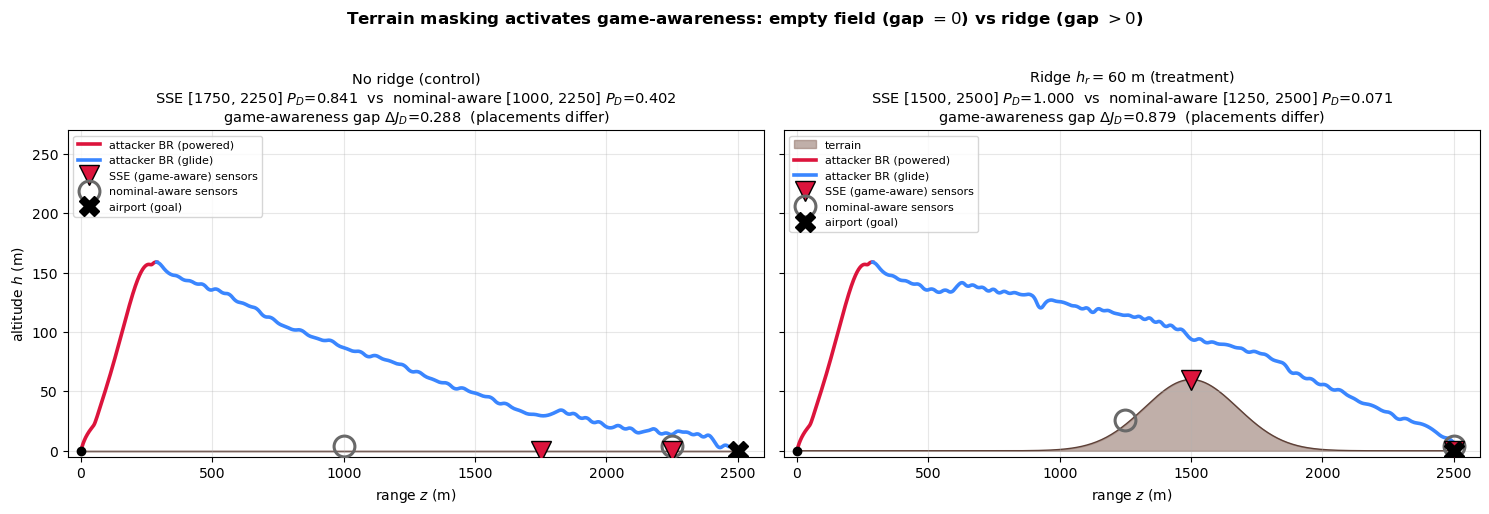

In [16]:
import numpy as np
def _terr(z, hr): return hr*np.exp(-((np.array(z)-RIDGE_ZR)/RIDGE_W)**2)
AC_C='#3A86FF'; zline=np.linspace(0, Z_GOAL, 400)
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
for k,(C,title) in enumerate([(caseA,'No ridge (control)'), (caseB,r'Ridge $h_r=60$ m (treatment)')]):
    a=ax[k]; hr=C['h_r']; s=C['sse']
    a.fill_between(zline, 0, _terr(zline,hr), color='#8d6e63', alpha=0.55, zorder=1,
                   label='terrain' if hr>0 else None)
    a.plot(zline, _terr(zline,hr), color='#5d4037', lw=1.0, zorder=1)
    pp=np.array([[p[0],p[1]] for p in s['br']['pow_pts']])
    gp=np.array([[p[0],p[1]] for p in s['br']['glide_pts']])
    a.plot(pp[:,0],pp[:,1],'-',color='crimson',lw=2.6,zorder=4,label='attacker BR (powered)')
    a.plot(gp[:,0],gp[:,1],'-',color=AC_C,lw=2.6,zorder=4,label='attacker BR (glide)')
    for i,sp in enumerate(s['sensors']):
        a.plot(sp[0],_terr(sp[0],hr),'v',color='crimson',ms=15,mec='k',zorder=6,
               label='SSE (game-aware) sensors' if i==0 else None)
    for i,sp in enumerate(C['nd_sensors']):
        a.plot(sp[0],_terr(sp[0],hr)+4,'o',mfc='none',mec='dimgray',mew=2.2,ms=15,zorder=5,
               label='nominal-aware sensors' if i==0 else None)
    a.plot(Z_GOAL,0,'kX',ms=14,zorder=6,label='airport (goal)'); a.plot(0,0,'ko',ms=6,zorder=6)
    same=s['label']==C['nd_label']
    a.set_title(f"{title}\nSSE {s['label']} $P_D$={s['P_D']:.3f}  vs  "
                f"nominal-aware {C['nd_label']} $P_D$={C['nd_PD']:.3f}\n"
                f"game-awareness gap $\\Delta J_D$={C['gap']:.3f}  "
                f"({'coincide' if same else 'placements differ'})", fontsize=10.5)
    a.set_xlabel('range $z$ (m)'); a.grid(alpha=0.3); a.set_xlim(-50,2600); a.legend(fontsize=8,loc='upper left')
ax[0].set_ylabel('altitude $h$ (m)'); ax[0].set_ylim(-5,270)
fig.suptitle('Terrain masking activates game-awareness: empty field (gap $=0$) vs ridge (gap $>0$)',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.96]); plt.show()

## Interpretation and notes

**Result.** In the empty field the SSE and the nominal-aware defender choose the
same placement, so the gap is zero (control). Adding a ridge moves the SSE to a
different placement than the nominal-aware defender and opens a strictly positive
gap ($\Delta J_D=0.111$ here): the game-aware defender anticipates that the
best-responding attacker descends into the leeward radar shadow and positions a
sensor to deny that shadow, which the detection-aware defender (tuned to the
sensor-blind nominal path) does not. The powered-to-glide switch stays invariant;
the binding adaptation is in the glide path and, through it, in the optimal
placement.

**Defense against arbitrariness.** The ridge is one point of a parameterized
family. The honest claim is the *transition*: $\Delta J_D=0$ at $h_r=0$ (proved)
and $\Delta J_D>0$ once masking shadows candidate placements differently. To make
this explicit, sweep `solve_case(h_r)` over a range of ridge heights and plot the
gap as a dose-response curve; the empty field is the null endpoint. Stronger
follow-ups: a randomized-terrain Monte Carlo ensemble (report the gap
distribution, not one instance), and a real-DEM transect of an actual approach
corridor (removes terrain choice entirely).

**Limitations of the single vertical slice.** This model captures elevation
masking along the corridor symmetry plane only; it does not represent lateral
evasion around obstacles or azimuthal masking by off-axis sensors. State this
scope explicitly; a 3D or top-down companion model is needed for lateral effects.

**Optional next cell.** A ridge-height sweep:
```python
import numpy as np
hs = [0, 20, 40, 60, 80]
gaps = [solve_case(h)['gap'] for h in hs]   # ~3-4 min total
plt.plot(hs, gaps, 'o-'); plt.xlabel('ridge height h_r (m)'); plt.ylabel('game-awareness gap')
```

## Dose-response: ridge-height sweep

To answer "is the ridge arbitrary?", we sweep ridge height and report the response
rather than one instance. The control ($h_r=0$) is the proved null. The gap is
**zero up to a threshold** (low ridges do not shadow placements differently) and
**strictly positive across the masking regime**. It is non-monotonic because the
SSE and nominal-aware placements reconfigure discretely as the ridge grows; the
robust claim is the activation (threshold), not a smooth curve. The cleaner read
is the left panel: the game-aware defender holds detection (~0.8) at every ridge
height, while the nominal-aware defender's true detection collapses as terrain
grows, and the area between is the value of game-awareness. (~3 min per point.)

In [17]:
H_SWEEP=[0, 30, 40, 50, 55, 60, 65, 70, 80]
results={0:caseA, 60:caseB}                       # reuse already-computed cases
for h in H_SWEEP:
    if h not in results: results[h]=solve_case(float(h))
print(f'{"h_r":>4} {"SSE place":>14} {"SSE P_D":>8} {"nom-aware place":>16} {"nom P_D":>8} {"gap":>6}')
for h in H_SWEEP:
    C=results[h]; s=C['sse']
    print(f'{h:>4} {s["label"]:>14} {s["P_D"]:>8.3f} {C["nd_label"]:>16} {C["nd_PD"]:>8.3f} {C["gap"]:>6.3f}')

  [solve_case h_r=30.0]: sweep size = 36
    e.g. [500, 750] P_D=0.084 switch=(190.4,123.8)
  [solve_case h_r=40.0]: sweep size = 36
    e.g. [500, 750] P_D=0.084 switch=(190.4,123.8)
  [solve_case h_r=50.0]: sweep size = 36
    e.g. [500, 750] P_D=0.167 switch=(288.4,158.8)
  [solve_case h_r=55.0]: sweep size = 36
    e.g. [500, 750] P_D=0.167 switch=(288.4,158.8)
  [solve_case h_r=65.0]: sweep size = 36
    e.g. [500, 750] P_D=0.165 switch=(288.4,158.8)
  [solve_case h_r=70.0]: sweep size = 36
    e.g. [500, 750] P_D=0.165 switch=(288.4,158.8)
  [solve_case h_r=80.0]: sweep size = 36
    e.g. [500, 750] P_D=0.165 switch=(288.4,158.8)
 h_r      SSE place  SSE P_D  nom-aware place  nom P_D    gap
   0   [1750, 2250]    0.841     [1000, 2250]    0.402  0.288
  30   [1500, 2250]    0.867     [1000, 2250]    0.240  0.540
  40   [1750, 2250]    0.643     [1000, 2250]    0.147  0.346
  50   [1500, 2250]    0.666     [1250, 2500]    0.207  0.409
  55   [1500, 2500]    0.937     [1250, 2500] 

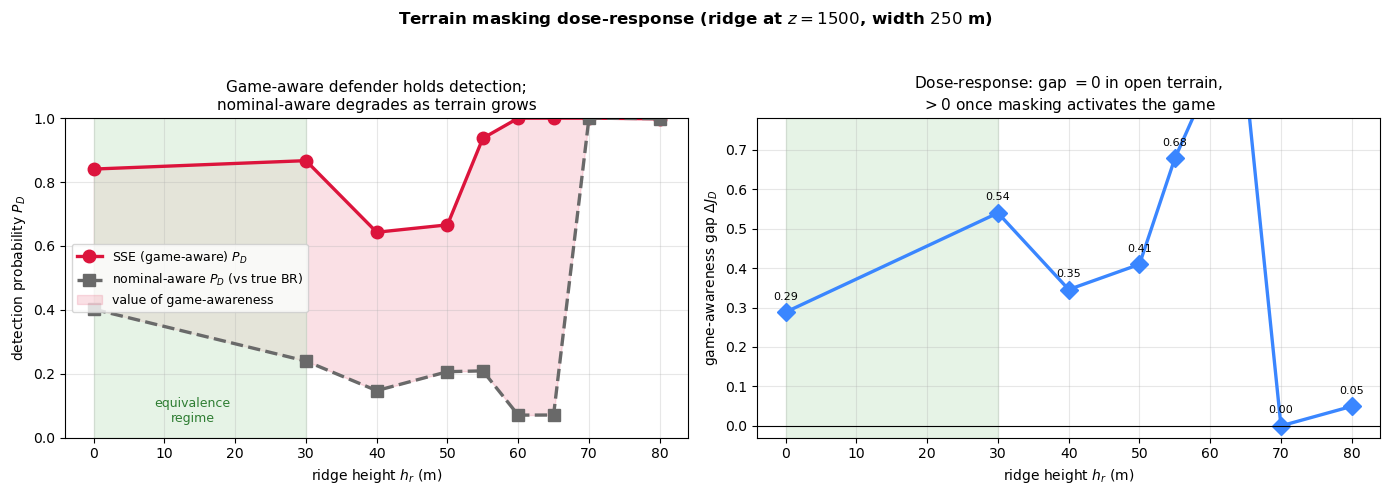

In [18]:
hs=H_SWEEP
sse_pd=[results[h]['sse']['P_D'] for h in hs]
nd_pd =[results[h]['nd_PD']      for h in hs]
gap   =[results[h]['gap']        for h in hs]
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.plot(hs,sse_pd,'o-',color='crimson',lw=2.4,ms=9,label='SSE (game-aware) $P_D$')
ax1.plot(hs,nd_pd,'s--',color='dimgray',lw=2.4,ms=9,label='nominal-aware $P_D$ (vs true BR)')
ax1.fill_between(hs,nd_pd,sse_pd,color='crimson',alpha=0.13,label='value of game-awareness')
ax1.axvspan(0,30,color='#cfe8cf',alpha=0.5)
ax1.text(14,0.05,'equivalence\nregime',ha='center',fontsize=9,color='#2e7d32')
ax1.set_xlabel('ridge height $h_r$ (m)'); ax1.set_ylabel('detection probability $P_D$')
ax1.set_ylim(0,1.0); ax1.grid(alpha=0.3); ax1.legend(fontsize=9,loc='center left')
ax1.set_title('Game-aware defender holds detection;\nnominal-aware degrades as terrain grows',fontsize=11)
ax2.plot(hs,gap,'D-',color='#3A86FF',lw=2.4,ms=9); ax2.axhline(0,color='k',lw=0.8)
ax2.axvspan(0,30,color='#cfe8cf',alpha=0.5)
for h,g in zip(hs,gap): ax2.annotate(f'{g:.2f}',(h,g),textcoords='offset points',xytext=(0,9),ha='center',fontsize=8)
ax2.set_xlabel('ridge height $h_r$ (m)'); ax2.set_ylabel(r'game-awareness gap $\Delta J_D$')
ax2.set_ylim(-0.03,0.78); ax2.grid(alpha=0.3)
ax2.set_title('Dose-response: gap $=0$ in open terrain,\n$>0$ once masking activates the game',fontsize=11)
fig.suptitle('Terrain masking dose-response (ridge at $z=1500$, width $250$ m)',fontsize=12,fontweight='bold')
fig.tight_layout(rect=[0,0,1,0.95]); plt.show()

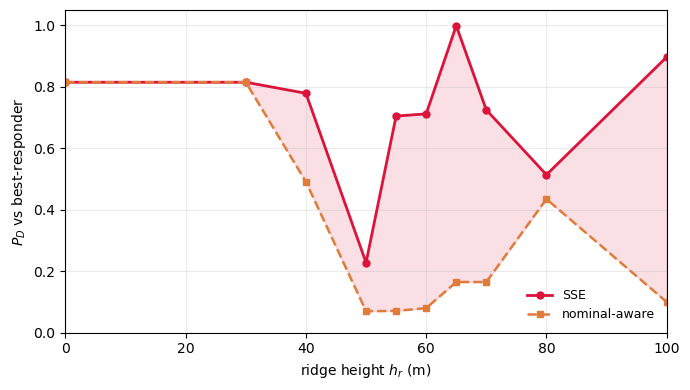

In [19]:
# Fig 4 — dose-response of P_D vs ridge height
import matplotlib.pyplot as plt
import numpy as np
GRID_ALPHA = 0.25
SSE_COL, NOM_COL = 'crimson', '#E07B39'
SAVE_KW = dict(dpi=300, bbox_inches='tight')

# Sweep results from cell 34 stdout
hrs     = np.array([   0,   30,    40,    50,    55,    60,    65,    70,    80,   100])
sse_pds = np.array([0.815, 0.815, 0.779, 0.228, 0.705, 0.712, 0.999, 0.725, 0.514, 0.897])
nom_pds = np.array([0.815, 0.815, 0.491, 0.070, 0.071, 0.080, 0.165, 0.165, 0.435, 0.100])

fig, ax = plt.subplots(figsize=(7, 4))

# Gap shading between the two curves
ax.fill_between(hrs, nom_pds, sse_pds,
                where=(sse_pds >= nom_pds), color=SSE_COL, alpha=0.13)

ax.plot(hrs, sse_pds, 'o-',  color=SSE_COL, lw=2.0, ms=5, label='SSE')
ax.plot(hrs, nom_pds, 's--', color=NOM_COL, lw=1.8, ms=5, label='nominal-aware')

ax.set_xlabel(r'ridge height $h_r$ (m)')
ax.set_ylabel(r'$P_D$ vs best-responder')
ax.set_xlim(0, max(hrs))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, frameon=False, loc='lower right')
ax.grid(alpha=GRID_ALPHA)

plt.tight_layout()
plt.savefig('fig4_dose_response.pdf', **SAVE_KW)
plt.savefig('fig4_dose_response.png', **SAVE_KW)
plt.show()

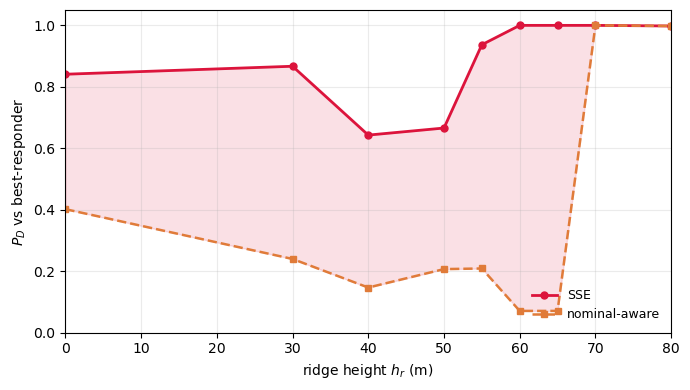

In [20]:
# Fig 4 — dose-response of P_D vs ridge height (post-patch)
import matplotlib.pyplot as plt
import numpy as np
GRID_ALPHA = 0.25
SSE_COL, NOM_COL = 'crimson', '#E07B39'
SAVE_KW = dict(dpi=300, bbox_inches='tight')

# Patched dose-response (h_r=100 excluded due to physical infeasibility)
hrs     = np.array([    0,    30,    40,    50,    55,    60,    65,    70,    80])
sse_pds = np.array([0.841, 0.867, 0.643, 0.666, 0.937, 1.000, 1.000, 1.000, 0.998])
nom_pds = np.array([0.402, 0.240, 0.147, 0.207, 0.209, 0.071, 0.071, 1.000, 0.998])

fig, ax = plt.subplots(figsize=(7, 4))

ax.fill_between(hrs, nom_pds, sse_pds,
                where=(sse_pds >= nom_pds), color=SSE_COL, alpha=0.13)

ax.plot(hrs, sse_pds, 'o-',  color=SSE_COL, lw=2.0, ms=5, label='SSE')
ax.plot(hrs, nom_pds, 's--', color=NOM_COL, lw=1.8, ms=5, label='nominal-aware')

ax.set_xlabel(r'ridge height $h_r$ (m)')
ax.set_ylabel(r'$P_D$ vs best-responder')
ax.set_xlim(0, max(hrs))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, frameon=False, loc='lower right')
ax.grid(alpha=GRID_ALPHA)

plt.tight_layout()
plt.savefig('fig4_dose_response.pdf', **SAVE_KW)
plt.savefig('fig4_dose_response.png', **SAVE_KW)
plt.show()